In [3]:
import numpy as np
import matplotlib.pyplot as plt

#  1. DATASET ÉTENDU À EXACTEMENT 55 ÉTUDIANTS (SESSION RATTRAPAGE)
# Matrice brute de 55 lignes (étudiants) et 7 colonnes.
# Variables : [Heures d'étude, Sommeil, Score Stress, Participation %, Sport, Temps d'écran, Note finale]
raw_data = np.array([
    [5, 6, 6, 55, 2, 4, 11], [2, 4, 8, 20, 0, 8, 7], [6, 7, 4, 65, 3, 3, 13],
    [1, 5, 9, 15, 1, 6, 5],  [4, 6, 5, 50, 2, 4, 10], [3, 5, 7, 35, 1, 5, 8],
    [7, 8, 3, 75, 4, 2, 14], [2, 6, 7, 30, 0, 7, 6],  [5, 5, 5, 60, 2, 3, 11],
    [3, 4, 8, 40, 1, 6, 9],  [6, 6, 4, 70, 3, 3, 12], [1, 3, 9, 10, 0, 9, 4],
    [4, 7, 6, 45, 2, 5, 10], [2, 5, 8, 25, 1, 7, 6],  [6, 7, 3, 68, 2, 3, 12],
    [2, 5, 8, 22, 0, 7, 6],  [7, 7, 4, 80, 4, 2, 15], [3, 6, 6, 38, 1, 5, 9],
    [5, 6, 5, 58, 2, 4, 11], [1, 4, 9, 12, 0, 8, 4],  [4, 5, 6, 48, 1, 4, 10],
    [2, 4, 7, 28, 0, 6, 7],  [6, 8, 3, 72, 3, 2, 13], [3, 5, 8, 33, 1, 5, 8],
    [5, 7, 4, 62, 2, 3, 12], [0, 3, 10, 5, 0, 10, 3], [7, 6, 3, 85, 3, 1, 16],
    [3, 4, 7, 42, 1, 6, 9],  [4, 6, 5, 52, 2, 3, 10], [2, 5, 9, 18, 0, 8, 5],
    [6, 6, 5, 66, 3, 4, 12], [1, 5, 8, 16, 0, 7, 6],  [5, 8, 4, 60, 4, 2, 11],
    [3, 5, 7, 30, 1, 6, 8],  [7, 7, 2, 78, 3, 2, 14], [2, 3, 9, 21, 0, 9, 5],
    [4, 6, 6, 47, 2, 4, 10], [3, 6, 7, 36, 1, 5, 8],  [6, 7, 4, 69, 2, 3, 13],
    [1, 4, 8, 14, 0, 8, 4],  [5, 5, 6, 57, 1, 4, 11], [2, 5, 7, 26, 0, 7, 7],
    [7, 8, 3, 82, 4, 1, 15], [3, 4, 8, 41, 1, 5, 9],  [4, 7, 5, 50, 2, 3, 10],
    [2, 6, 8, 24, 0, 8, 6],  [6, 6, 3, 74, 3, 2, 13], [1, 3, 9, 11, 0, 9, 3],
    [5, 6, 5, 61, 2, 4, 11], [3, 5, 6, 34, 1, 6, 8],
    # 5 Nouveaux étudiants pour arriver aux 55 demandés
    [6, 7, 4, 75, 3, 2, 14], [2, 4, 8, 20, 0, 8, 6],  [5, 6, 5, 58, 2, 4, 11],
    [1, 3, 9, 12, 0, 9, 4],  [7, 8, 2, 89, 4, 1, 16]
])

# Slicing : On extrait les 6 premières colonnes (les caractéristiques/features)
X_data = raw_data[:, :6]

# Slicing : On isole la 7ème colonne (les notes finales qui serviront de labels)
notes = raw_data[:, 6]

# Calcul de la moyenne pour chaque colonne (axe 0) pour le centrage
X_mean = np.mean(X_data, axis=0)

# Calcul de l'écart-type pour chaque colonne pour la réduction
X_std = np.std(X_data, axis=0)

# Normalisation Standardisée (Z-score) : indispensable pour que la PCA ne soit pas biaisée par les différences d'unités
X_norm = (X_data - X_mean) / X_std

In [4]:
# 2. ALGORITHME PCA
class MyPCA:
    # Initialisation de la classe avec le nombre de dimensions cibles souhaitées
    def __init__(self, n_components):
        self.n_components = n_components # Nombre de composantes (ex: 2 pour la 2D)
        self.components = None            # Stockera les vecteurs propres (les nouveaux axes)
        self.mean = None                  # Moyenne des données calculée durant le fit
        self.eigenvalues = None           # Stockera les valeurs propres (variance expliquée)

    # Entraînement du modèle sur la matrice d'entrée X
    def fit(self, X):
        # Enregistrement et calcul de la moyenne du tableau d'entrée
        self.mean = np.mean(X, axis=0)
        # Centrage des données autour de zéro
        X_centered = X - self.mean
        # Calcul de la matrice de covariance entre les variables
        covariance_matrix = np.cov(X_centered.T)
        # Extraction des valeurs propres (variance) et vecteurs propres (directions) de la matrice
        eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

        # Transposition des vecteurs propres pour manipuler chaque composante par ligne
        eigenvectors = eigenvectors.T
        # Récupération des indices de tri dans l'ordre décroissant des valeurs propres
        idxs = np.argsort(eigenvalues)[::-1]
        # Tri des valeurs propres de la plus grande à la plus petite
        self.eigenvalues = eigenvalues[idxs]
        # Sélection exclusive des "n_components" premiers vecteurs principaux triés
        self.components = eigenvectors[idxs][0:self.n_components]

    # Projection des données d'origine dans le nouvel espace vectoriel créé
    def transform(self, X):
        # Nouveau centrage des données d'entrée basé sur la moyenne de référence
        X_centered = X - self.mean
        # Calcul du produit matriciel (projection) entre les données centrées et la transposée de nos axes principaux
        return np.dot(X_centered, self.components.T)

# Instanciation de notre algorithme PCA fait maison pour obtenir 2 dimensions
pca = MyPCA(n_components=2)
# Ajustement géométrique du modèle sur nos données normalisées
pca.fit(X_norm)
# Transformation des données initiales vers les coordonnées PC1 et PC2
X_projected = pca.transform(X_norm)

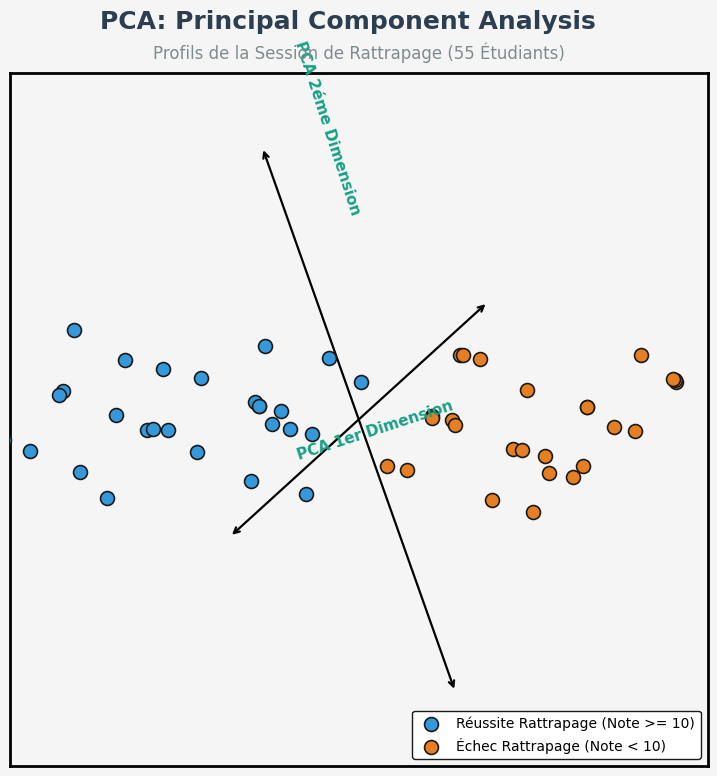

In [5]:
# 3. INTERFACE GRAPHIQUE AJUSTÉE ET SÉCURISÉE (ANTI-DARK MODE)
# Initialisation de l'objet graphique (hauteur et largeur égales pour un aspect carré 1:1)
fig, ax = plt.subplots(figsize=(9, 9))

# Paramétrage de la couleur d'arrière-plan globale (évite que le mode sombre du logiciel ne prenne le dessus)
fig.patch.set_facecolor('#f5f5f5')
ax.set_facecolor('#f5f5f5')

# Création des masques logiques (booléens) pour trier les notes
reussite_mask = notes >= 10  # Étudiant ayant obtenu la moyenne ou plus
echec_mask = notes < 10      # Étudiant n'ayant pas atteint la moyenne

# Plot du nuage de points pour les réussites (en bleu clair, taille 100, avec une bordure fine)
ax.scatter(X_projected[reussite_mask, 0], X_projected[reussite_mask, 1],
           color='#3498db', label='Réussite Rattrapage (Note >= 10)', s=100, edgecolors='#1a1a1a', linewidths=1.2, zorder=3)

# Plot du nuage de points pour les échecs (en orange, taille 100, avec une bordure fine)
ax.scatter(X_projected[echec_mask, 0], X_projected[echec_mask, 1],
           color='#e67e22', label='Échec Rattrapage (Note < 10)', s=100, edgecolors='#1a1a1a', linewidths=1.2, zorder=3)

# ---- CALCUL ET AJUSTEMENT GÉOMÉTRIQUE DES AXES DE LA PCA ----
# Constante de multiplication pour étirer graphiquement les flèches vectorielles de l'origine vers l'extérieur
scale = 3.5

# Construction mathématique de l'Axe 1 (PC1)
v1 = pca.components[0] * scale
# Dessin de la flèche bidirectionnelle (<->) de l'Axe 1 passant par (0,0)
ax.annotate('', xy=(v1[0], v1[1]), xytext=(-v1[0], -v1[1]),
            arrowprops=dict(arrowstyle="<->", color="black", lw=1.6, shrinkA=0, shrinkB=0), zorder=2)
# Ajout de l'étiquette textuelle inclinée pour l'Axe 1
ax.text(v1[0]*0.5, v1[1]*0.5 + 0.2, "PCA 1er Dimension", color="#16a085", fontsize=11, fontweight='bold', rotation=18)

# Construction mathématique de l'Axe 2 (PC2)
v2 = pca.components[1] * scale
# Dessin de la flèche bidirectionnelle (<->) de l'Axe 2 passant par (0,0)
ax.annotate('', xy=(v2[0], v2[1]), xytext=(-v2[0], -v2[1]),
            arrowprops=dict(arrowstyle="<->", color="black", lw=1.6, shrinkA=0, shrinkB=0), zorder=2)
# Ajout de l'étiquette textuelle inclinée pour l'Axe 2
ax.text(-v2[0]*0.7, -v2[1]*0.7 + 0.2, "PCA 2éme Dimension", color="#16a085", fontsize=11, fontweight='bold', rotation=-72)

# ---- CONFIGURATION DES TITRES ET BORDURES ----
# Ajout du titre principal de la figure
fig.suptitle("PCA: Principal Component Analysis", fontsize=18, fontweight='bold', color='#2c3e50', y=0.95)
# Ajout du sous-titre ciblant le contexte des 55 étudiants
ax.set_title("Profils de la Session de Rattrapage (55 Étudiants)", fontsize=12, color='#7f8c8d', pad=10)

# Désactivation explicite des lignes de grille pour respecter le style épuré de l'image d'exemple
ax.grid(False)

# Boucle pour épaissir et appliquer une couleur noire uniforme sur les 4 bordures (spines) du repère
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2.0)

# Paramétrage des limites d'affichage x et y pour centrer parfaitement le repère
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)

# Masquage des graduations numériques par défaut (ticks) sur les axes X et Y
ax.set_xticks([])
ax.set_yticks([])

# Positionnement d'une légende opaque en bas à droite avec texte forcé en noir pour contrer les thèmes sombres
ax.legend(loc="lower right", framealpha=1.0, facecolor='#ffffff', edgecolor='#1a1a1a', labelcolor='black', fontsize=10)

# Commande pour rendre le graphique et finaliser l'affichage
plt.show()